In [3]:
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

import numpy as np 
import tensorflow as tf 
from tensorflow.keras import * 

from tensorflow.keras.layers import * 
from tensorflow.keras.models import load_model, save_model 
from tensorflow.keras import Model
import tensorflow.keras.utils as utils
from keras.datasets import mnist 

from includes.fully_connected_opt_weight_generation import * 

### Original Floating-point Model 

In [4]:
def Net(): 
    # inputs = Input(shape=x_train.shape[1:])
    inputs = Input(shape=(28, 28, 1))
    x = Flatten()(inputs)
    x = Dense(100)(x)
    x = ReLU()(x)
    x = Dense(10)(x)
    predictions = Softmax()(x)
    return Model(inputs=inputs, outputs=predictions)

In [5]:
epochs = 5 
num_classes = 10 
(x_train, y_train_num), (x_test, y_test_num) = mnist.load_data() 
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)
y_train = utils.to_categorical(y_train_num, num_classes)
y_test = utils.to_categorical(y_test_num, num_classes)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

model = Net()
model.load_weights('neural_network_model.h5')

(60000, 28, 28, 1) (10000, 28, 28, 1) (60000, 10) (10000, 10)


In [6]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 28, 28, 1)]       0         
_________________________________________________________________
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 100)               78500     
_________________________________________________________________
re_lu (ReLU)                 (None, 100)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 10)                1010      
_________________________________________________________________
softmax (Softmax)            (None, 10)                0         
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
_________________________________________________________

In [7]:
length = y_test.shape[0]
positives = 0
res = 0 
for i in range(length): 
    pred = model(x_test[i:i+1]).numpy().squeeze()
    y_test = (y_test > 0.5)
    pred_cast = (pred > 0.5)
    if i == 5 or i == 10 or i == 15: 
        print("y_test   :", y_test[i])
        print("pred     :", pred)
        print("pred_cast:", pred_cast)
        print("res    :", y_test[i]==pred)
        print('\n')

    positives = np.sum(y_test[i] == pred)
    if positives == 10: 
        res += 1
        
print("Accuracy:", res/length)

y_test   : [False  True False False False False False False False False]
pred     : [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
pred_cast: [False  True False False False False False False False False]
res    : [ True  True  True  True  True  True  True  True  True  True]


y_test   : [ True False False False False False False False False False]
pred     : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
pred_cast: [ True False False False False False False False False False]
res    : [ True  True  True  True  True  True  True  True  True  True]


y_test   : [False False False False False  True False False False False]
pred     : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
pred_cast: [False False False False False  True False False False False]
res    : [ True  True  True  True  True  True  True  True  True  True]


Accuracy: 0.9674


In [8]:
"""
quantize numpy array
return:
x_q: quantized array
x_fp: reverse quantized array to float
"""
def quantize_array(x, bit_depth=8):
    min_x = x.min() 
    max_x = x.max()

    #find number of integer bits to represent this range
    int_bits = int(np.ceil(np.log2(max(abs(min_x),abs(max_x)))))
    
    if int_bits < 0: int_bits = 0

    frac_bits = bit_depth - 1 - int_bits #remaining bits are fractional bits (1-bit for sign)

    #floating point weights are scaled and rounded to [-2^(bit-1),2^(bit-1)-1], which are used in 
    #the fixed-point operations on the actual hardware (i.e., microcontroller)
    x_q = np.round(x*(2**frac_bits))

    # To quantify the impact of quantized weights, scale them back to
    # original range to run inference using quantized weights
    x_fp = x_q/(2**frac_bits)
    
    return x_q, x_fp, int_bits, frac_bits


"""
compute frac_bits based on max and min list
used for activation(feature map) quantization
"""
def min_max_quantize(max_list, min_list, bit_depth=8):
    frac_list = []
    for i in range(len(max_list)):
        int_bits = int(np.ceil(np.log2(max(abs(min_list[i]),abs(max_list[i])))))
        if int_bits < 0: int_bits = 0
        frac_bits = bit_depth - 1 - int_bits #remaining bits are fractional bits (1-bit for sign)
        frac_list.append(frac_bits)
    return frac_list

### Quantized Model

In [9]:
def QNet(bit=32, shift_list=[]):
    shift = False 
    if bit != 32: 
        shift = True 
    # input shape = (28, 28, 1)
    input = Input(shape=x_train.shape[1:], name='input')
    x = Flatten(name='flatten')(input)
    x = Dense(100, name='fc1')(x)
    if shift:
        x = x / 2**shift_list[0]
        x = tf.floor(x)
        x = tf.clip_by_value(x, -2**(bit-1), 2**(bit-1)-1)
    x = ReLU(name='relu2')(x)
    
    x = Dense(10, name='fc2')(x)
    if shift: 
        x = x / 2**shift_list[1]
        x = tf.floor(x)
        x = tf.clip_by_value(x, -2**(bit-1), 2**(bit-1)-1)
    else:
        x_out = x
    x_out = Softmax(name='softmax')(x)
    return Model(input, x_out)


# To check if the layer name went in correctly
model = QNet()
model.load_weights('neural_network_model.h5')
layer_names = [] 
complete_layers_name = [] 

for layer in model.layers: 
    if len(layer.get_weights()) != 0:
        layer_names.append(layer.name)
    complete_layers_name.append(layer.name)

complete_layers_name.remove('input')

layer_num = len(layer_names)
complete_layer_num = len(complete_layers_name)
print("Layer (With Weights) Names: ", layer_names)
print("TOTAL Layer Names: ", complete_layers_name)

Layer (With Weights) Names:  ['fc1', 'fc2']
TOTAL Layer Names:  ['flatten', 'fc1', 'relu2', 'fc2', 'softmax']


In [10]:
"""
 intermediate feature map retrieval 
 for max and min value acquisition and computing quantization format
"""
intermediate_output = [model.get_layer('input').output]
print("Intermediate Output::", intermediate_output)

for i in range(layer_num):
    intermediate_output.append(model.get_layer(layer_names[i]).output)
print("Intermediate Output::", intermediate_output)
# intermediate output of input and other weighted layers are stored in a list

intermediate_layer_model = Model(inputs=model.input, outputs=intermediate_output)
print(intermediate_layer_model)
print(intermediate_output)
print('\n')
#-------------------------------

# Get output from all layers
complete_intermediate_output = []
for i in range(complete_layer_num):
    complete_intermediate_output.append(model.get_layer(complete_layers_name[i]).output)
print("Complete Intermediate Output::", complete_intermediate_output)

complete_intermediate_layer_model = Model(inputs=model.input, outputs=complete_intermediate_output)
print(complete_intermediate_layer_model)

Intermediate Output:: [<KerasTensor: shape=(None, 28, 28, 1) dtype=float32 (created by layer 'input')>]
Intermediate Output:: [<KerasTensor: shape=(None, 28, 28, 1) dtype=float32 (created by layer 'input')>, <KerasTensor: shape=(None, 100) dtype=float32 (created by layer 'fc1')>, <KerasTensor: shape=(None, 10) dtype=float32 (created by layer 'fc2')>]
[<KerasTensor: shape=(None, 28, 28, 1) dtype=float32 (created by layer 'input')>, <KerasTensor: shape=(None, 100) dtype=float32 (created by layer 'fc1')>, <KerasTensor: shape=(None, 10) dtype=float32 (created by layer 'fc2')>]


Complete Intermediate Output:: [<KerasTensor: shape=(None, 784) dtype=float32 (created by layer 'flatten')>, <KerasTensor: shape=(None, 100) dtype=float32 (created by layer 'fc1')>, <KerasTensor: shape=(None, 100) dtype=float32 (created by layer 'relu2')>, <KerasTensor: shape=(None, 10) dtype=float32 (created by layer 'fc2')>, <KerasTensor: shape=(None, 10) dtype=float32 (created by layer 'softmax')>]


In [11]:
print(x_test[1].shape)
print(x_test[10:11].shape)

(28, 28, 1)
(1, 28, 28, 1)


In [12]:
"""
Extract the maximum and minimum value for 
the output of each layer specified in the previous cell
"""
frac_bits_output_list = [] 
max_list = []
min_list = [] 
for i in range(length):
    pred = intermediate_layer_model(x_test[i:i+1])
    for i in range(len(pred)):
        pred_np = pred[i].numpy()
        max_np = pred_np.max()
        min_np = pred_np.min()
        if len(max_list) != len(pred):
            max_list.append(max_np)
            min_list.append(min_np)
        else:
            if max_np > max_list[i]:
                max_list[i] = max_np
            if min_np < min_list[i]:
                min_list[i] = min_np

print("Max list::", max_list)
print("Min list::", min_list)
print()
bit_depth = 16 
frac_bits_activation_list = min_max_quantize(max_list, min_list, bit_depth=bit_depth)

print("input: ", frac_bits_activation_list)
for i in range(layer_num):
    print(i+1, " ", layer_names[i], " ", frac_bits_activation_list[i+1])

Max list:: [255.0, 3004.2854, 5885.325]
Min list:: [0.0, -5195.4893, -6726.576]

input:  [7, 2, 2]
1   fc1   2
2   fc2   2


### Quantization (16 bits)


In [13]:
bit_depth = 16 
frac_bits_weight_list = [] 
frac_bits_bias_list = [] 
q_weight_list = [] 
q_bias_list = [] 

for i in range(layer_num):
    weight, bias = model.get_layer(layer_names[i]).get_weights()
    q_weight, f_weight, int_bits_weight, frac_bits_weight = quantize_array(weight, bit_depth=bit_depth)
    q_bias, f_bias, int_bits_bias, frac_bits_bias = quantize_array(bias, bit_depth=bit_depth)
    
    q_weight_list.append(q_weight)
    q_bias_list.append(q_bias)
    frac_bits_weight_list.append(frac_bits_weight)
    frac_bits_bias_list.append(frac_bits_bias)
    print('***********')
    print(layer_names[i] + '-- weight -- Q' + str(int_bits_weight) + '.' + str(frac_bits_weight))
    print(layer_names[i] + '-- bias -- Q' + str(int_bits_bias) + '.' + str(frac_bits_bias))    


for i in range (layer_num):
    weight, bias = model.get_layer(layer_names[i]).get_weights() 
    print(weight.shape)
    print(weight)


***********
fc1-- weight -- Q0.15
fc1-- bias -- Q0.15
***********
fc2-- weight -- Q0.15
fc2-- bias -- Q0.15
(784, 100)
[[ 0.06980211 -0.0471039   0.07018308 ... -0.04993114  0.00432672
  -0.04626109]
 [ 0.03548399  0.00047283  0.0222187  ... -0.04664665 -0.06269415
  -0.07531276]
 [ 0.0017812  -0.0597802   0.08164401 ...  0.06891018 -0.06305015
  -0.04295257]
 ...
 [ 0.03586942 -0.0488013  -0.08236834 ... -0.03764437  0.01125707
  -0.0121093 ]
 [-0.04803103  0.03369293  0.02976385 ...  0.06197168  0.0663954
  -0.05304138]
 [ 0.05900097  0.02547726 -0.00020182 ...  0.00583119 -0.00540396
   0.00158145]]
(100, 10)
[[-4.90232855e-01 -4.93713289e-01  1.41819909e-01  1.92434072e-01
   1.08522266e-01  8.14066529e-02 -1.11517601e-01 -2.08587408e-01
   5.00289723e-02  2.44992271e-01]
 [-2.74448931e-01 -2.70437717e-01 -3.25048685e-01  3.00452620e-01
  -8.92969370e-01  5.12955546e-01  2.79704276e-02  1.77752033e-01
   6.71009049e-02  2.21972883e-01]
 [-2.81264603e-01 -4.36912298e-01 -5.28269053e

In [14]:
# computing bias shift-left and output shift-right
bias_shift_list = np.array(frac_bits_weight_list) + np.array(frac_bits_activation_list[0:-1]) - np.array(frac_bits_bias_list)
output_shift_list = np.array(frac_bits_weight_list) + np.array(frac_bits_activation_list[0:-1]) - np.array(frac_bits_activation_list[1:])  
print(bias_shift_list)
print(output_shift_list)

[7 2]
[20 15]


In [15]:
q_model = QNet(bit=bit_depth, shift_list=output_shift_list)

for i in range(layer_num):
    q_model.get_layer(layer_names[i]).set_weights([q_weight_list[i], q_bias_list[i] * (2**bias_shift_list[i])])

# evaluation 
length = y_test.shape[0]
positives = 0
for i in range(length):
    pred = q_model(np.round(x_test[i:i+1]*(2**frac_bits_activation_list[0])))
    pred_cast = pred > 0.5

    if i == 0 or i == 5 or i == 10:
        print("y_test   :", y_test[i])
        print("pred     :", pred)
        print("pred_cast:", pred_cast)
        print("res    :", y_test[i]==pred_cast)
        print('\n')
    positives += np.sum(y_test[i] == pred)
    if positives == 10:
        res += 1
    
print("Accuracy after quantization: ", res / length)

y_test   : [False False False False False False False  True False False]
pred     : tf.Tensor(
[[2.3195230e-16 2.5436657e-13 2.0611535e-09 1.5229981e-08 1.2664167e-14
  2.1151311e-19 5.2428857e-22 1.0000000e+00 4.6588858e-15 1.5229981e-08]], shape=(1, 10), dtype=float32)
pred_cast: tf.Tensor([[False False False False False False False  True False False]], shape=(1, 10), dtype=bool)
res    : tf.Tensor([[ True  True  True  True  True  True  True  True  True  True]], shape=(1, 10), dtype=bool)


y_test   : [False  True False False False False False False False False]
pred     : tf.Tensor(
[[2.7649310e-07 2.7649310e-07 6.0901660e-03 4.5000575e-02 1.0437986e-17
  4.5000575e-02 5.5535124e-06 4.1035215e-05 9.0386075e-01 7.5158619e-07]], shape=(1, 10), dtype=float32)
pred_cast: tf.Tensor([[False False False False False False False False  True False]], shape=(1, 10), dtype=bool)
res    : tf.Tensor([[ True False  True  True  True  True  True  True False  True]], shape=(1, 10), dtype=bool)


y_te

### Saving quantized weight as .h (Clang) file

In [16]:
"""
Reordering and then saving onto a header file
"""

reordered_weight_list = []
for i in range(len(q_weight_list)):
    # convolution layer
    if len(q_weight_list[i].shape) == 4:
        reordered_weight_list.append(np.moveaxis(q_weight_list[i], 2, 0))
    # dense layer
    else: 
        reordered_weight_list.append(np.moveaxis(q_weight_list[i], 1, 0))

# flatten the weight tensor 
reordered_weight_flatten_list = []
for i in range(len(q_weight_list)): 
    # convolution layer 
    if len(reordered_weight_list[i].shape) == 4:
        reordered_weight_flatten_list.append(reordered_weight_list[i].flatten('F'))
    # dense layer
    else: 
        reordered_weight_flatten_list.append(reordered_weight_list[i].flatten())

# save 
f = open('./quantized_weight.h', 'w')
for i in range(len(q_weight_list)): 
    print('********' + layer_names[i] + '********')
    print('Bias shift: ', bias_shift_list[i])
    print('Output shift: ', output_shift_list[i])
    print('Bias: ', q_bias_list[i].astype(np.int16))
    print('Weight: ', reordered_weight_flatten_list[i].astype(np.int16))
    
    f.write('#define ' + layer_names[i].upper() + '_WT {' + str(reordered_weight_flatten_list[i].astype(np.int16).tolist())[1:-1] + '}\n')
    f.write('#define ' + layer_names[i].upper() + '_BIAS {' + str(q_bias_list[i].astype(np.int16).tolist())[1:-1] + "}\n")
    f.write('#define ' + layer_names[i].upper() + '_BIAS_LSHIFT ' + str(bias_shift_list[i]) + "\n")
    f.write('#define ' + layer_names[i].upper() + '_OUT_RSHIFT ' + str(output_shift_list[i]) + "\n\n")
    
f.close()

********fc1********
Bias shift:  7
Output shift:  20
Bias:  [  263 -1458  1524  4062 -1266 -1595  3355   647   929  7091   945  -430
  -179  3342  1048  1135  1211   397 -1041   906 -1920  5510  2800  1368
   370  5013  2517    69  -877  -378   359  -943  -146  3691  -923  2547
  -417   547  2939 -2187  2507  3241  3429  4072  -154  4825    86 -2686
  2652  1113  -719  1629  -445  3915  3896  -436   487 -1100 -1167  1662
  1370 -2480  1244   267  1082 -1554  4774   491  2319  4254 -1123  -631
  3226   934  -989   898 -1640   939  1663 -1425  -491  2136  -867  1768
  -897  1651  2126  -561  -839  3127  -259  1723  1557 -3462  -720  2873
 -2329 -1238  -421  -564]
Weight:  [ 2287  1163    58 ...  -397 -1738    52]
********fc2********
Bias shift:  2
Output shift:  15
Bias:  [-2013 -1289  4345 -2187    31  3009 -1376   169  -635  -655]
Weight:  [-16064  -8993  -9216 -18010   6349 -12625 -12634   8613  -2282  -5106
 -18603   2917   -970 -15606    553 -24673  -5784 -14280  -4472   1727
  -852

In [17]:
q_reordered_weight_list = []

for i in range(layer_num): 
    print(q_weight_list[i].shape)
    input_dim, output_dim = q_weight_list[i].shape
    q_expanded_weight_list = np.reshape(q_weight_list[i], (output_dim, input_dim, 1, 1))
    reordered_weights = convert_to_x4_q15_weights(q_expanded_weight_list)
    final_weights = np.reshape(reordered_weights, (output_dim, input_dim))
    q_reordered_weight_list.append(final_weights)

# flatten the weight tensor 
weight_flatten_list = []
for i in range(len(q_reordered_weight_list)): 
    # convolution layer 
    if len(q_reordered_weight_list[i].shape) == 4:
        weight_flatten_list.append(q_reordered_weight_list[i].flatten('F'))
    # dense layer
    else: 
        weight_flatten_list.append(q_reordered_weight_list[i].flatten())


f = open('./opt_quantized_weight.h', 'w')
for i in range(len(q_weight_list)): 
    print('********' + layer_names[i] + '********')
    print('Bias shift: ', bias_shift_list[i])
    print('Output shift: ', output_shift_list[i])
    print('Bias: ', q_bias_list[i].astype(np.int16))
    print('Weight: ', weight_flatten_list[i].astype(np.int16))
    
    f.write('#define ' + layer_names[i].upper() + '_WT {' + str(reordered_weight_flatten_list[i].astype(np.int16).tolist())[1:-1] + '}\n')
    f.write('#define ' + layer_names[i].upper() + '_BIAS {' + str(q_bias_list[i].astype(np.int16).tolist())[1:-1] + "}\n")
    f.write('#define ' + layer_names[i].upper() + '_BIAS_LSHIFT ' + str(bias_shift_list[i]) + "\n")
    f.write('#define ' + layer_names[i].upper() + '_OUT_RSHIFT ' + str(output_shift_list[i]) + "\n\n")
f.close()

(784, 100)
(100, 10)
********fc1********
Bias shift:  7
Output shift:  20
Bias:  [  263 -1458  1524  4062 -1266 -1595  3355   647   929  7091   945  -430
  -179  3342  1048  1135  1211   397 -1041   906 -1920  5510  2800  1368
   370  5013  2517    69  -877  -378   359  -943  -146  3691  -923  2547
  -417   547  2939 -2187  2507  3241  3429  4072  -154  4825    86 -2686
  2652  1113  -719  1629  -445  3915  3896  -436   487 -1100 -1167  1662
  1370 -2480  1244   267  1082 -1554  4774   491  2319  4254 -1123  -631
  3226   934  -989   898 -1640   939  1663 -1425  -491  2136  -867  1768
  -897  1651  2126  -561  -839  3127  -259  1723  1557 -3462  -720  2873
 -2329 -1238  -421  -564]
Weight:  [ 2287 -1544  2683 ...  2022  -177    52]
********fc2********
Bias shift:  2
Output shift:  15
Bias:  [-2013 -1289  4345 -2187    31  3009 -1376   169  -635  -655]
Weight:  [-16064 -16178 -18603  18707  -8528   5044   8574  -8482   4647   6306
  -4619  -4707   -339   -505  -2560   3594   3556   2668

### Saving Intermediate Output Data of the Neural Network 

In [18]:
intermediate_output = []
intermediate_output.append(q_model.get_layer('input').output)

for i in range(layer_num):
    intermediate_output.append(q_model.get_layer(layer_names[i]).output)

q_intermediate_layer_model = Model(inputs=q_model.input, outputs=intermediate_output)
sample_output = q_intermediate_layer_model.predict(np.round(x_test[0:1]*(2**frac_bits_activation_list[0])))

# save with weight reordering
f = open("./sample_input_output.h", "w")
temp = np.squeeze(sample_output[0], axis=0)
temp = temp.transpose(2, 0, 1)
temp = temp.flatten("F")
f.write("#define " + "INPUT_DATA {" + str(temp.astype(np.int16).tolist())[1:-1] + "}\n")

for i in range(layer_num):
    temp = np.squeeze(sample_output[i+1], axis=0)
    print(temp.shape)
    if len(temp.shape) == 3:
        print(sample_output[i])
        temp = temp.transpose(2, 0, 1)
        temp = temp.flatten("F")
    
    temp = temp.astype(np.int32) >> output_shift_list[i]
    f.write("#define " + layer_names[i].upper() + " {" + str(temp.tolist())[1:-1] + "}\n")

f.close()
print("finished reordering and writing input and output to file")


(100,)
(10,)
finished reordering and writing input and output to file


### Demonstrating Intermediate Layer Output 
to guide how to deal with dimensional issues in CMSIS 

RAW INPUT
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 128, 128, 0, 128, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 128, 128, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

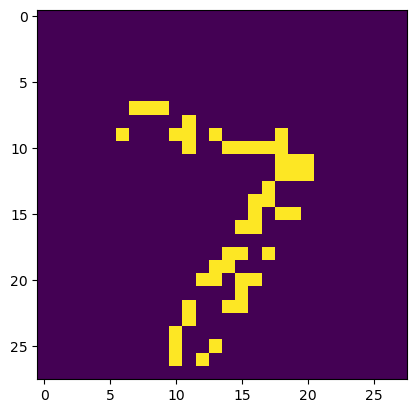

In [19]:
# raw input ------------------------------------------
input_result = []
input_result.append(q_model.get_layer('input').output)
q_intermediate_input = Model(inputs=q_model.input, outputs=input_result)
sample_output = q_intermediate_input.predict(np.round(x_test[0:1]*(2**frac_bits_activation_list[0])))
temp0 = np.squeeze(sample_output, axis=0)
temp = temp0.flatten()
temp = temp.astype(np.int16).tolist()
print("RAW INPUT\n", temp)

plt.imshow(temp0)
print(temp0.shape)

In [20]:
# processed input ----------------------------------------- matches exactly 
input_result = []
input_result.append(q_model.get_layer('input').output)
q_intermediate_input = Model(inputs=q_model.input, outputs=input_result)
sample_output = q_intermediate_input.predict(np.round(x_test[0:1]*(2**frac_bits_activation_list[0])))
temp = np.squeeze(sample_output, axis=0)
temp = temp.transpose(2, 0, 1)
print("AFTER TRANSPOSE\n", temp.astype(np.int16).tolist())

temp = temp.flatten("F")
print("AFTER FLATTEN\n", temp.astype(np.int16).tolist())

temp = temp.astype(np.int16).tolist()
print("FINAL PROCESSED INPUT\n", temp)


AFTER TRANSPOSE
 [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 128, 128, 0, 128, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 128, 128, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0